# Predicción de costos médicos con Machine Learning

## Continuación del ejercicio de costo de calefacción

En el ejercicio anterior, la regresión múltiple con **Statsmodels** se utilizó principalmente con un propósito **inferencial**: explicar la relación entre las variables independientes y el costo de calefacción, evaluar significancia estadística y revisar los supuestos del modelo.

Este segundo ejercicio cambia el foco hacia la **predicción**. La organización desea estimar los cargos médicos anuales de una persona a partir de su edad, sexo, índice de masa corporal (BMI), número de hijos, condición de fumador y región. El objetivo no es demostrar causalidad, sino construir un modelo que generalice bien ante personas no observadas y que pueda apoyar estimaciones, presupuestos y simulaciones de escenarios.

> **Pregunta de negocio:** ¿qué costo médico anual puede esperarse para un nuevo perfil y con qué nivel de error suele predecir el modelo?

### Objetivos

1. Explorar y validar los datos.
2. Preparar variables numéricas y categóricas sin fuga de información.
3. Comparar modelos mediante validación cruzada.
4. Evaluar el modelo seleccionado en un conjunto de prueba no utilizado durante el entrenamiento.
5. Interpretar sus predicciones y desplegar una interfaz sencilla con Gradio.
6. Distinguir la modelación inferencial de la modelación predictiva.

## 1. Configuración del entorno

Este bloque instala Gradio en Colab e importa las librerías. Se fija una semilla para que la partición y los resultados puedan reproducirse. Durante la validación automática local, la instalación se omite si la librería ya está disponible.

In [1]:
# Instala/actualiza Gradio en el entorno de Google Colab.
%pip -q install "gradio>=5,<7"

import io
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)
print("Entorno preparado.")

Entorno preparado.


## 2. Carga del archivo

El bloque funciona en dos contextos:

- En **Google Colab**, solicita subir `insurance.csv`.
- En un entorno local, busca primero el archivo junto al notebook o en la carpeta `upload`.

Después normaliza los nombres de columnas y verifica que estén presentes las variables requeridas. Esta validación temprana evita entrenar un modelo con un archivo equivocado.

In [2]:
REQUIRED_COLUMNS = {"age", "sex", "bmi", "children", "smoker", "region", "charges"}

def load_insurance_data():
    candidates = [Path("insurance.csv"), Path("upload/insurance.csv")]
    for path in candidates:
        if path.exists():
            print(f"Archivo local cargado: {path}")
            return pd.read_csv(path)

    try:
        from google.colab import files
        print("Seleccione el archivo insurance.csv")
        uploaded = files.upload()
        filename = next(iter(uploaded))
        return pd.read_csv(io.BytesIO(uploaded[filename]))
    except ImportError as exc:
        raise FileNotFoundError("No se encontró insurance.csv. Colóquelo junto al notebook.") from exc

df = load_insurance_data()
df.columns = df.columns.str.strip().str.lower()

missing_columns = REQUIRED_COLUMNS - set(df.columns)
if missing_columns:
    raise ValueError(f"Faltan columnas requeridas: {sorted(missing_columns)}")

print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
display(df.head())

Seleccione el archivo insurance.csv


Saving insurance.csv to insurance.csv
Dimensiones: 1,338 filas × 8 columnas


,id,age,sex,bmi,children,smoker,region,charges
0,0,19,female,27.900,0,yes,southwest,16884.92400
1,1,18,male,33.770,1,no,southeast,1725.55230
2,2,28,male,33.000,3,no,southeast,4449.46200
3,3,33,male,22.705,0,no,northwest,21984.47061
4,4,32,male,28.880,0,no,northwest,3866.85520


## 3. Auditoría inicial y calidad de datos

Se revisan tipos, faltantes, duplicados, categorías y estadísticos descriptivos. `id`, si existe, se excluye porque identifica registros, pero no describe el riesgo médico; usarlo podría inducir patrones artificiales.

In [3]:
audit = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "faltantes": df.isna().sum(),
    "%_faltantes": (df.isna().mean() * 100).round(2),
    "valores_unicos": df.nunique()
})
display(audit)
print(f"Filas duplicadas: {df.duplicated().sum()}")

for column in ["sex", "smoker", "region"]:
    print(f"\nDistribución de {column}:")
    display(df[column].value_counts(dropna=False).to_frame("frecuencia"))

display(df[["age", "bmi", "children", "charges"]].describe().T.round(2))

,tipo,faltantes,%_faltantes,valores_unicos
id,int64,0,0.0,1338
age,int64,0,0.0,47
sex,object,0,0.0,2
bmi,float64,0,0.0,548
children,int64,0,0.0,6
smoker,object,0,0.0,2
region,object,0,0.0,4
charges,float64,0,0.0,1337


Filas duplicadas: 0

Distribución de sex:


,frecuencia
sex,
male,676
female,662



Distribución de smoker:


,frecuencia
smoker,
no,1064
yes,274



Distribución de region:


,frecuencia
region,
southeast,364
southwest,325
northwest,325
northeast,324


,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.21,14.05,18.00,27.00,39.00,51.00,64.00
bmi,1338.0,30.66,6.10,15.96,26.30,30.40,34.69,53.13
children,1338.0,1.09,1.21,0.00,0.00,1.00,2.00,5.00
charges,1338.0,13270.42,12110.01,1121.87,4740.29,9382.03,16639.91,63770.43


## 4. EDA: distribución de la variable objetivo

El histograma permite observar la forma de `charges`; el boxplot ayuda a detectar valores extremos. Los valores altos no se eliminan automáticamente: pueden representar casos médicos reales y son importantes para la predicción. Sólo deberían excluirse con evidencia de error de captura.

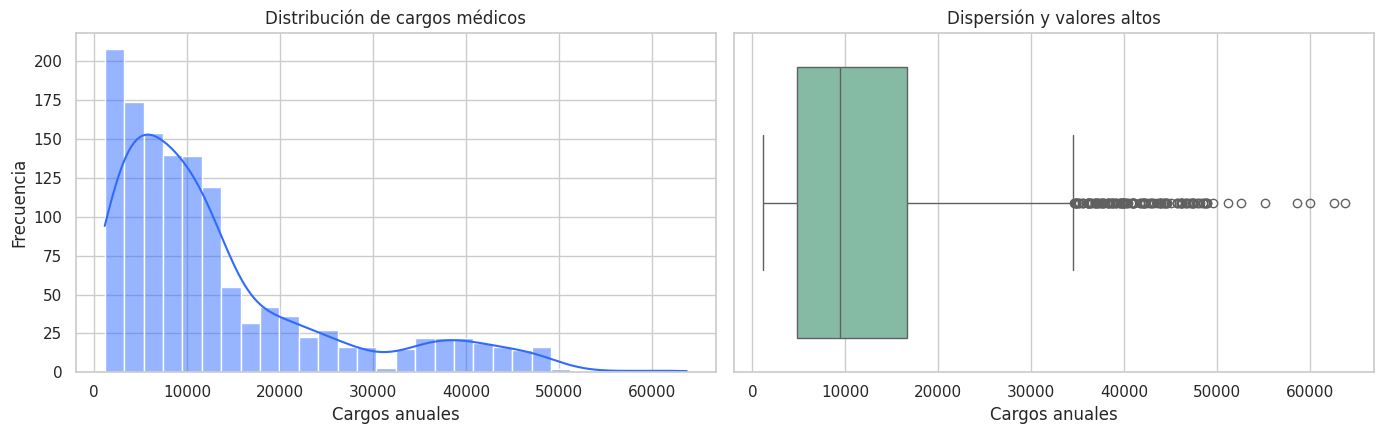

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(df["charges"], kde=True, ax=axes[0], color="#2F6BFF")
axes[0].set(title="Distribución de cargos médicos", xlabel="Cargos anuales", ylabel="Frecuencia")
sns.boxplot(x=df["charges"], ax=axes[1], color="#7CC4A5")
axes[1].set(title="Dispersión y valores altos", xlabel="Cargos anuales")
plt.tight_layout()
plt.show()

## 5. EDA: relaciones entre predictores y costo

Las gráficas comparan el costo con edad, BMI y condición de fumador. El color permite detectar interacciones visuales: por ejemplo, el efecto del BMI puede ser distinto entre fumadores y no fumadores. Estas relaciones guían la selección de modelos capaces de capturar no linealidad.

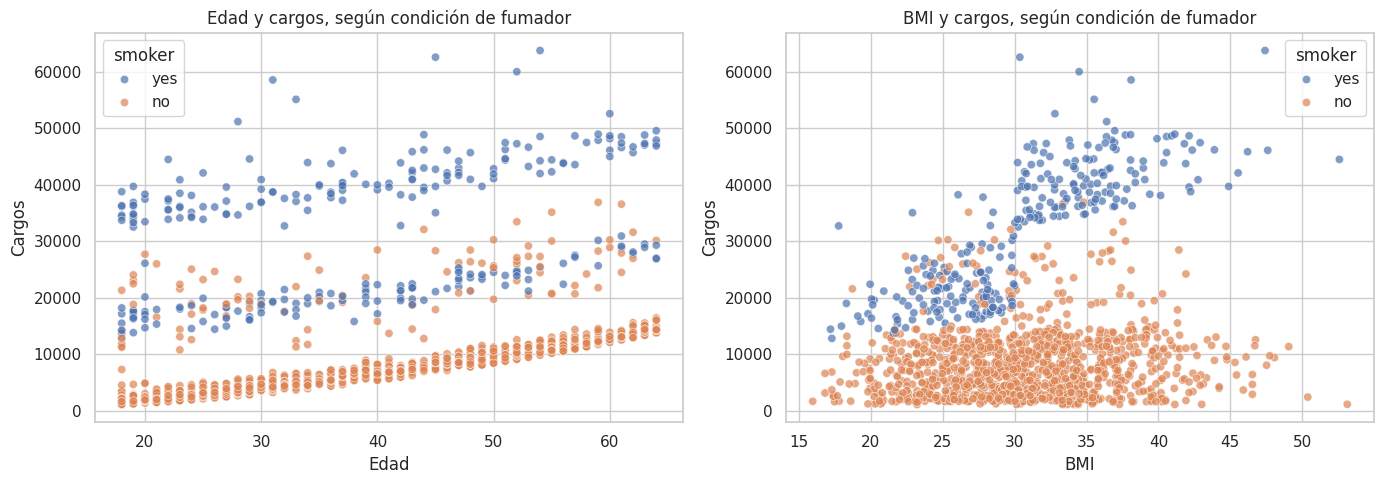

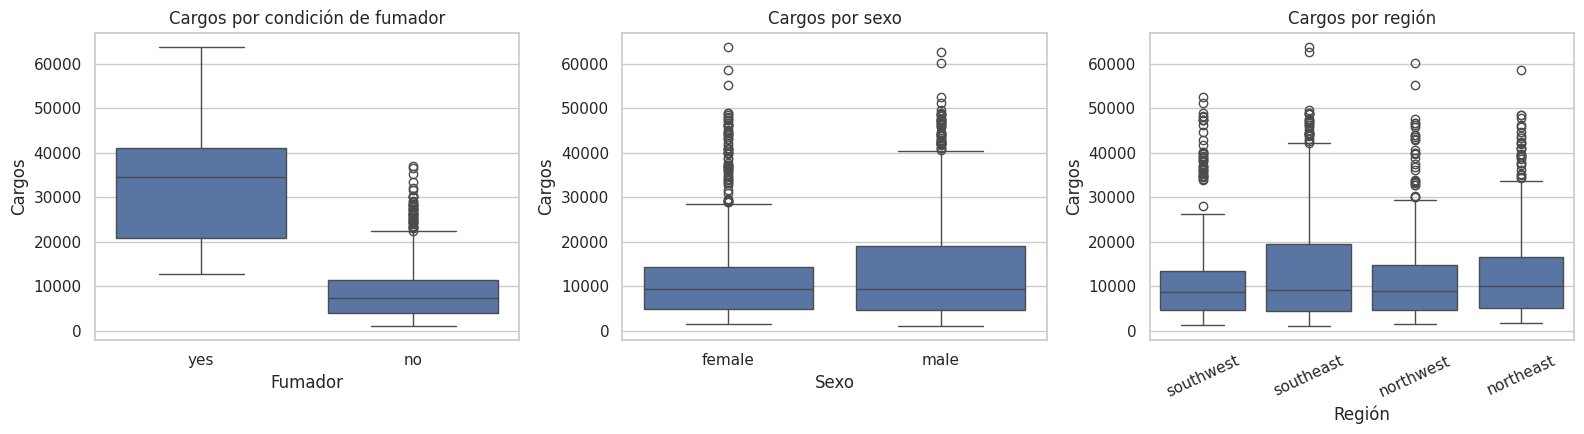

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x="age", y="charges", hue="smoker", alpha=.70, ax=axes[0])
axes[0].set(title="Edad y cargos, según condición de fumador", xlabel="Edad", ylabel="Cargos")
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", alpha=.70, ax=axes[1])
axes[1].set(title="BMI y cargos, según condición de fumador", xlabel="BMI", ylabel="Cargos")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.boxplot(data=df, x="smoker", y="charges", ax=axes[0])
axes[0].set(title="Cargos por condición de fumador", xlabel="Fumador", ylabel="Cargos")
sns.boxplot(data=df, x="sex", y="charges", ax=axes[1])
axes[1].set(title="Cargos por sexo", xlabel="Sexo", ylabel="Cargos")
sns.boxplot(data=df, x="region", y="charges", ax=axes[2])
axes[2].tick_params(axis="x", rotation=25)
axes[2].set(title="Cargos por región", xlabel="Región", ylabel="Cargos")
plt.tight_layout()
plt.show()

## 6. Matriz de correlación numérica

La correlación resume asociaciones lineales entre variables numéricas. No mide relaciones no lineales, no incorpora las variables categóricas y no implica causalidad; por ello es una pieza del EDA, no una conclusión definitiva.

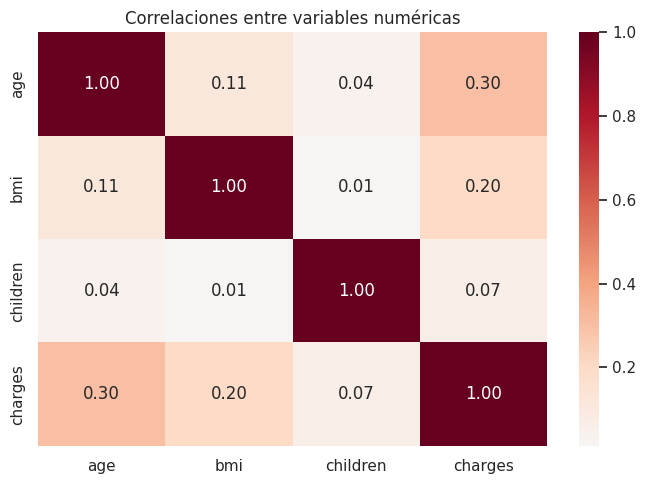

In [6]:
numeric_for_eda = ["age", "bmi", "children", "charges"]
plt.figure(figsize=(7, 5))
sns.heatmap(df[numeric_for_eda].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Correlaciones entre variables numéricas")
plt.tight_layout()
plt.show()

## 7. Separación de entrenamiento y prueba

Se reserva 20% de los registros como prueba final. El modelo no ve estas observaciones durante el entrenamiento ni durante la comparación. Esto aproxima el escenario real de predecir personas nuevas.

La estratificación por `smoker` conserva aproximadamente la proporción de fumadores en ambos subconjuntos, una precaución importante porque esta variable está fuertemente asociada con el costo.

In [7]:
feature_columns = ["age", "sex", "bmi", "children", "smoker", "region"]
target_column = "charges"

X = df[feature_columns].copy()
y = df[target_column].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=X["smoker"]
)

print(f"Entrenamiento: {len(X_train):,} registros")
print(f"Prueba: {len(X_test):,} registros")
print("Proporción de fumadores:")
display(pd.DataFrame({
    "entrenamiento": X_train["smoker"].value_counts(normalize=True),
    "prueba": X_test["smoker"].value_counts(normalize=True)
}).round(3))

Entrenamiento: 1,070 registros
Prueba: 268 registros
Proporción de fumadores:


,entrenamiento,prueba
smoker,,
no,0.795,0.795
yes,0.205,0.205


## 8. Preprocesamiento reproducible

El `ColumnTransformer` aplica transformaciones distintas por tipo de variable:

- Numéricas: imputación por mediana y estandarización.
- Categóricas: imputación por moda y codificación one-hot.

Todo queda dentro de un `Pipeline`. Así, cada pliegue de validación aprende las transformaciones sólo con sus datos de entrenamiento, reduciendo la fuga de información. `handle_unknown="ignore"` permite recibir categorías nuevas sin romper el flujo.

In [8]:
numeric_features = ["age", "bmi", "children"]
categorical_features = ["sex", "smoker", "region"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

models = {
    "Regresión lineal": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=250, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=1
    ),
    "Gradient Boosting": HistGradientBoostingRegressor(
        learning_rate=0.06, max_iter=300, max_leaf_nodes=15,
        l2_regularization=1.0, random_state=RANDOM_STATE
    )
}

pipelines = {
    name: Pipeline([("preprocess", preprocessor), ("model", model)])
    for name, model in models.items()
}
print("Pipelines creados:", list(pipelines))

Pipelines creados: ['Regresión lineal', 'Random Forest', 'Gradient Boosting']


## 9. Comparación mediante validación cruzada

Se emplean cinco pliegues sobre el conjunto de entrenamiento. Las métricas son:

- **MAE:** error absoluto promedio, expresado en las mismas unidades monetarias que `charges`; es fácil de comunicar.
- **RMSE:** penaliza con mayor fuerza errores grandes, importante cuando subestimar casos costosos es riesgoso.
- **R²:** proporción de variabilidad explicada; puede ser negativo y no expresa el error en dinero.

Se selecciona el menor MAE promedio. La desviación estándar muestra estabilidad entre pliegues.

In [9]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

cv_rows = []
for name, pipeline in pipelines.items():
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    cv_rows.append({
        "Modelo": name,
        "MAE_CV": -scores["test_MAE"].mean(),
        "MAE_std": scores["test_MAE"].std(),
        "RMSE_CV": -scores["test_RMSE"].mean(),
        "R2_CV": scores["test_R2"].mean()
    })

cv_results = pd.DataFrame(cv_rows).sort_values("MAE_CV").reset_index(drop=True)
display(cv_results.round({"MAE_CV": 2, "MAE_std": 2, "RMSE_CV": 2, "R2_CV": 3}))

best_model_name = cv_results.loc[0, "Modelo"]
best_pipeline = pipelines[best_model_name]
print(f"Modelo seleccionado por menor MAE de validación: {best_model_name}")

,Modelo,MAE_CV,MAE_std,RMSE_CV,R2_CV
0,Random Forest,2577.20,279.55,4621.40,0.853
1,Gradient Boosting,2844.66,344.58,4792.07,0.842
2,Regresión lineal,4270.42,209.27,6208.27,0.736


Modelo seleccionado por menor MAE de validación: Random Forest


## 10. Entrenamiento final y evaluación fuera de muestra

El modelo ganador se ajusta con todo el conjunto de entrenamiento y se evalúa una sola vez en prueba. También se calcula MAPE sólo como referencia; en problemas monetarios puede ser inestable cuando los valores reales son pequeños, por lo que MAE y RMSE son las métricas principales.

In [10]:
best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test.to_numpy() - y_pred) / y_test.to_numpy())) * 100

test_metrics = pd.DataFrame({
    "Métrica": ["MAE", "RMSE", "R²", "MAPE (referencia)"],
    "Resultado": [mae, rmse, r2, mape]
})
display(test_metrics.round({"Resultado": 3}))

print(f"Interpretación: el error absoluto típico es aproximadamente {mae:,.0f} unidades monetarias.")
print(f"El modelo explica {r2:.1%} de la variación observada en el conjunto de prueba.")

,Métrica,Resultado
0,MAE,2645.199
1,RMSE,4525.425
2,R²,0.861
3,MAPE (referencia),34.058


Interpretación: el error absoluto típico es aproximadamente 2,645 unidades monetarias.
El modelo explica 86.1% de la variación observada en el conjunto de prueba.


## 11. Visualizaciones de desempeño

La primera gráfica compara valores reales y predichos: cuanto más cerca de la diagonal, mejor. La segunda muestra residuos (`real − predicción`); una nube aleatoria alrededor de cero es deseable. Patrones o apertura en forma de abanico indican segmentos donde el error cambia.

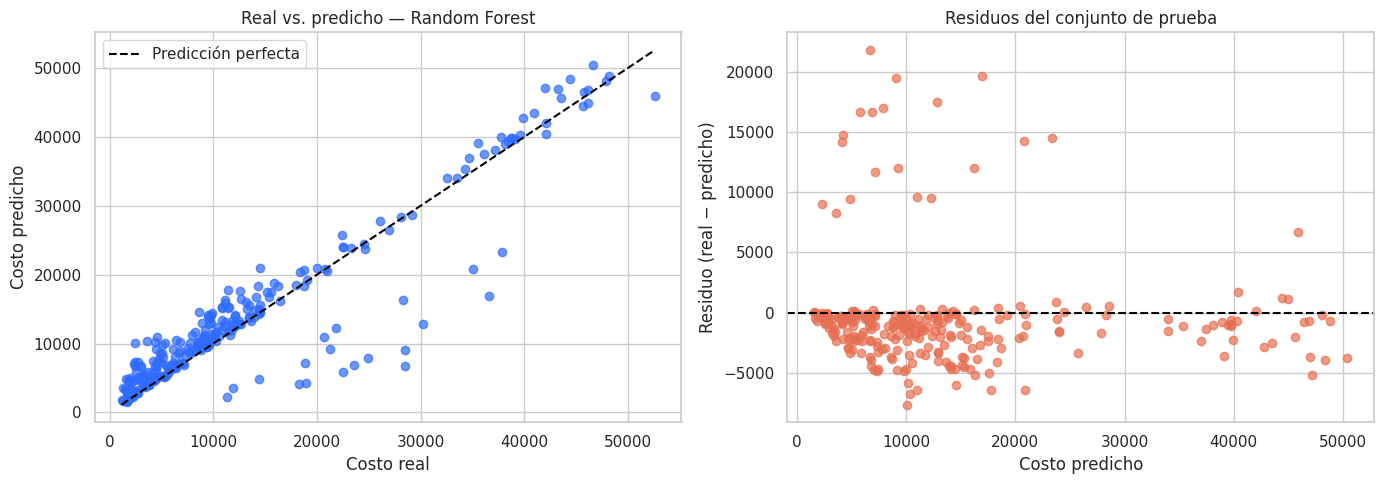

In [11]:
residuals = y_test.to_numpy() - y_pred
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=.70, color="#2F6BFF")
limits = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(limits, limits, "--", color="black", label="Predicción perfecta")
axes[0].set(title=f"Real vs. predicho — {best_model_name}", xlabel="Costo real", ylabel="Costo predicho")
axes[0].legend()

axes[1].scatter(y_pred, residuals, alpha=.70, color="#E76F51")
axes[1].axhline(0, linestyle="--", color="black")
axes[1].set(title="Residuos del conjunto de prueba", xlabel="Costo predicho", ylabel="Residuo (real − predicho)")
plt.tight_layout()
plt.show()

## 12. Análisis del error por segmentos

Una métrica global puede ocultar desempeño desigual. Se calcula MAE por condición de fumador, sexo y región. Los segmentos pequeños deben interpretarse con cautela; diferencias persistentes justificarían recopilar más datos o calibrar modelos específicos.

In [12]:
evaluation = X_test.copy()
evaluation["real"] = y_test
evaluation["predicho"] = y_pred
evaluation["error_absoluto"] = np.abs(evaluation["real"] - evaluation["predicho"])

for segment in ["smoker", "sex", "region"]:
    segment_metrics = evaluation.groupby(segment).agg(
        registros=("real", "size"),
        costo_real_promedio=("real", "mean"),
        MAE=("error_absoluto", "mean")
    ).sort_values("MAE", ascending=False)
    print(f"Desempeño por {segment}:")
    display(segment_metrics.round(2))

Desempeño por smoker:


,registros,costo_real_promedio,MAE
smoker,,,
no,213,8232.12,2811.75
yes,55,32496.62,2000.20


Desempeño por sex:


,registros,costo_real_promedio,MAE
sex,,,
male,132,14794.35,2712.66
female,136,11675.74,2579.72


Desempeño por region:


,registros,costo_real_promedio,MAE
region,,,
northeast,62,14009.32,2930.33
southeast,73,14490.84,2743.50
southwest,68,12344.47,2468.09
northwest,65,11921.88,2448.12


## 13. Importancia predictiva de las variables

La importancia por permutación mide cuánto empeora el MAE cuando se desordena una variable en el conjunto de prueba. Es independiente del tipo de algoritmo y mantiene las variables originales agrupadas.

> Una variable importante para predecir **no es necesariamente una causa**. Puede actuar como proxy, estar correlacionada con otra variable o reflejar sesgos del proceso de datos.

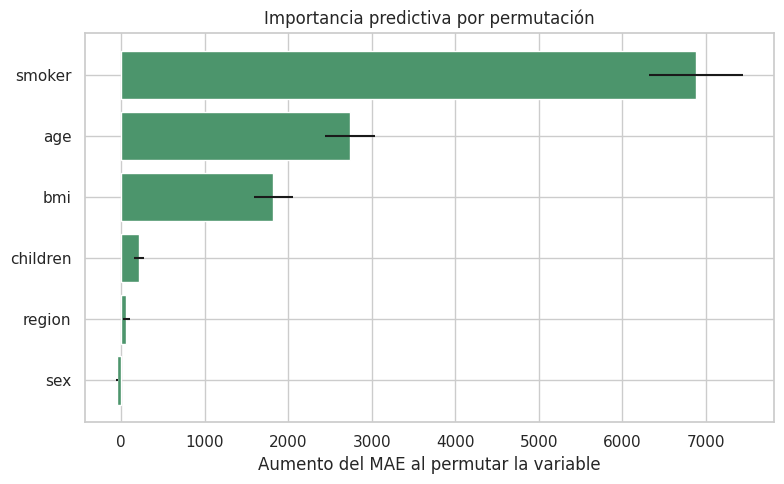

,variable,aumento_MAE,desviacion
4,smoker,6876.80,563.25
0,age,2735.91,300.09
2,bmi,1822.19,232.69
3,children,217.62,59.42
5,region,61.71,44.91
1,sex,-47.25,14.57


In [13]:
perm = permutation_importance(
    best_pipeline, X_test, y_test,
    scoring="neg_mean_absolute_error", n_repeats=20,
    random_state=RANDOM_STATE, n_jobs=1
)
importance = pd.DataFrame({
    "variable": X_test.columns,
    "aumento_MAE": perm.importances_mean,
    "desviacion": perm.importances_std
}).sort_values("aumento_MAE", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance["variable"], importance["aumento_MAE"],
         xerr=importance["desviacion"], color="#4C956C")
plt.xlabel("Aumento del MAE al permutar la variable")
plt.title("Importancia predictiva por permutación")
plt.tight_layout()
plt.show()
display(importance.sort_values("aumento_MAE", ascending=False).round(2))

## 14. Efectos parciales de variables numéricas

Los gráficos de dependencia parcial muestran cómo cambia, en promedio, la predicción al variar una característica y mantener la distribución de las demás. Son útiles para comprender el comportamiento del modelo, pero **no representan efectos causales** y pueden ser engañosos cuando existen combinaciones poco realistas o predictores altamente correlacionados.

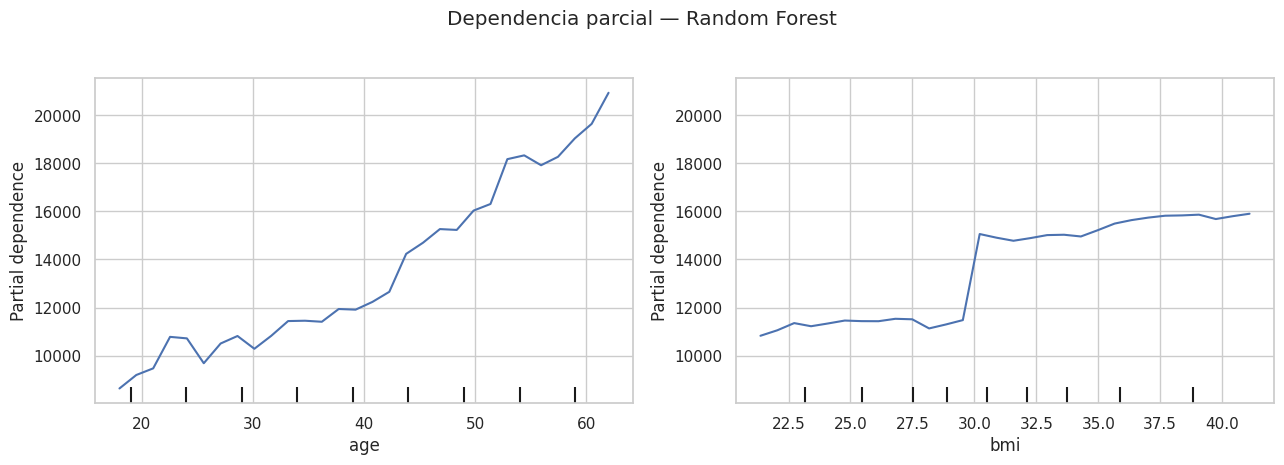

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
PartialDependenceDisplay.from_estimator(
    best_pipeline, X_train, features=["age", "bmi"], ax=ax,
    kind="average", grid_resolution=30
)
fig.suptitle(f"Dependencia parcial — {best_model_name}", y=1.03)
plt.tight_layout()
plt.show()

## 15. Intervalo empírico orientativo

Para comunicar incertidumbre, se usan los percentiles 10 y 90 de los residuos absolutos de validación fuera de pliegue. Es una banda empírica sencilla alrededor de la predicción, **no un intervalo de confianza inferencial ni una garantía individual**. En producción convendría utilizar predicción conformal y validar cobertura por segmento.

In [15]:
from sklearn.model_selection import cross_val_predict

oof_pred = cross_val_predict(best_pipeline, X_train, y_train, cv=cv, n_jobs=1)
absolute_oof_errors = np.abs(y_train.to_numpy() - oof_pred)
error_p80 = np.quantile(absolute_oof_errors, 0.80)
error_p90 = np.quantile(absolute_oof_errors, 0.90)

print(f"80% de los errores absolutos de validación fueron ≤ {error_p80:,.0f}")
print(f"90% de los errores absolutos de validación fueron ≤ {error_p90:,.0f}")

80% de los errores absolutos de validación fueron ≤ 3,264
90% de los errores absolutos de validación fueron ≤ 5,767


## 16. Guardado del pipeline

Se guarda el pipeline completo —preprocesamiento y modelo— para reutilizar exactamente las mismas transformaciones en la interfaz o en un servicio. Este archivo debe cargarse sólo desde una fuente confiable.

In [16]:
MODEL_FILE = "modelo_prediccion_costos_medicos.joblib"
joblib.dump(best_pipeline, MODEL_FILE)
print(f"Modelo guardado en: {MODEL_FILE}")

Modelo guardado en: modelo_prediccion_costos_medicos.joblib


## 17. Interfaz Gradio

La interfaz recibe un perfil, genera la predicción y muestra una banda orientativa basada en los errores observados en validación. En Google Colab cambie `RUN_GRADIO` a `True` y ejecute la celda. `share=True` crea un enlace temporal; no debe utilizarse con datos personales reales sin controles de privacidad y seguridad.

In [23]:
import gradio as gr

def predict_medical_cost(age, sex, bmi, children, smoker, region):
    new_person = pd.DataFrame([{
        "age": int(age), "sex": sex, "bmi": float(bmi),
        "children": int(children), "smoker": smoker, "region": region
    }])
    prediction = float(best_pipeline.predict(new_person)[0])
    lower = max(0, prediction - error_p90)
    upper = prediction + error_p90
    return (
        f"### Costo médico anual estimado: ${prediction:,.2f}\n"
        f"Banda empírica orientativa: **${lower:,.2f} a ${upper:,.2f}**\n\n"
        f"Modelo: {best_model_name}. La banda refleja errores históricos de validación; "
        "no es una cotización, diagnóstico médico ni intervalo causal."
    )

with gr.Blocks(title="Predicción de costos médicos") as demo:
    gr.Markdown("# Simulador predictivo de costos médicos")
    gr.Markdown("Ingrese un perfil hipotético. No utilice información personal identificable.")
    with gr.Row():
        with gr.Column():
            age_input = gr.Slider(18, 64, value=35, step=1, label="Edad")
            sex_input = gr.Radio(["female", "male"], value="female", label="Sexo")
            bmi_input = gr.Slider(15.0, 55.0, value=27.5, step=0.1, label="BMI")
        with gr.Column():
            children_input = gr.Slider(0, 5, value=0, step=1, label="Número de hijos")
            smoker_input = gr.Radio(["no", "yes"], value="no", label="¿Fumador?")
            region_input = gr.Dropdown(
                ["northeast", "northwest", "southeast", "southwest"],
                value="northeast", label="Región"
            )
    predict_button = gr.Button("Estimar costo", variant="primary")
    output = gr.Markdown()
    predict_button.click(
        predict_medical_cost,
        inputs=[age_input, sex_input, bmi_input, children_input, smoker_input, region_input],
        outputs=output
    )

RUN_GRADIO = True  # Cambiar a True en Google Colab
if RUN_GRADIO:
    demo.launch(share=True, debug=False)
else:
    print(predict_medical_cost(35, "female", 27.5, 0, "no", "northeast"))
    print("Interfaz construida. Cambie RUN_GRADIO=True para abrirla.")

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://22525096fe0f2f7c65.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 18. Inferencia estadística vs. Machine Learning predictivo

| Aspecto | Modelación inferencial | Machine Learning predictivo |
|---|---|---|
| Pregunta central | ¿Cómo se relaciona X con Y, controlando otras variables? | ¿Qué valor de Y tendrá un caso nuevo? |
| Prioridad | Interpretación, estimación de efectos, incertidumbre y pruebas de hipótesis | Generalización fuera de muestra y reducción del error predictivo |
| Evaluación típica | Coeficientes, intervalos de confianza, p-valores, supuestos y diagnóstico de residuos | Validación cruzada, conjunto de prueba, MAE, RMSE, R² y estabilidad por segmento |
| Complejidad | Suele favorecer especificaciones interpretables y justificadas | Puede favorecer relaciones no lineales, interacciones y ensambles |
| Supuestos | Son centrales para que la inferencia sea válida | Importan, pero el criterio decisivo es el desempeño futuro bajo datos comparables |
| Resultado | Evidencia sobre asociaciones; causalidad sólo con un diseño e identificación adecuados | Predicción útil; no demuestra causalidad ni significancia estadística |

### ¿Por qué es relevante distinguirlos?

Un modelo puede predecir muy bien y, aun así, no permitir afirmar que una variable **cause** el resultado. A la inversa, un coeficiente estadísticamente significativo puede tener poco valor predictivo o práctico. Confundir ambos objetivos conduce a decisiones deficientes: usar p-valores para elegir el mejor predictor, interpretar importancias como efectos causales o evaluar un modelo inferencial únicamente por su R².

### En la práctica real se combinan ambos enfoques

En proyectos de negocio maduros, los dos enfoques se complementan:

1. La inferencia ayuda a formular hipótesis, cuantificar asociaciones, justificar variables y entender mecanismos.
2. Machine Learning permite capturar patrones complejos y estimar resultados para casos futuros.
3. La validación fuera de muestra confirma si la solución generaliza.
4. El conocimiento del negocio, la evaluación causal cuando corresponda, la equidad y el monitoreo convierten el modelo en una decisión responsable.

Por ejemplo, una aseguradora podría usar el modelo predictivo para presupuestar costos y un análisis inferencial o causal separado para estudiar si una intervención preventiva reduce gastos. La predicción responde **cuánto podría costar**; la inferencia y el diseño causal ayudan a responder **por qué** y **qué ocurriría si se interviene**.

## 19. Conclusiones ejecutivas

Las conclusiones numéricas siguientes se generan con los resultados ejecutados para evitar afirmaciones prefabricadas. Al interpretar:

- Compare MAE y RMSE: una brecha amplia indica errores grandes en algunos casos.
- Revise R² junto con errores monetarios; ningún indicador aislado es suficiente.
- Observe los segmentos con mayor MAE antes de utilizar el modelo en decisiones.
- Trate las importancias como señales predictivas, no como causalidad.
- Antes de producción, incorpore datos más recientes, validación temporal, monitoreo de deriva, seguridad, privacidad, equidad y predicción conformal.

In [18]:
top_features = importance.sort_values("aumento_MAE", ascending=False).head(3)["variable"].tolist()
worst_rows = evaluation.nlargest(3, "error_absoluto")[["age", "bmi", "smoker", "region", "real", "predicho", "error_absoluto"]]

print("CONCLUSIONES BASADAS EN LA EJECUCIÓN")
print(f"1. El modelo seleccionado fue {best_model_name}, por obtener el menor MAE promedio en validación cruzada.")
print(f"2. En prueba obtuvo MAE=${mae:,.2f}, RMSE=${rmse:,.2f} y R²={r2:.3f}.")
print(f"3. Las variables con mayor importancia predictiva fueron: {', '.join(top_features)}.")
print(f"4. El 90% de los errores absolutos fuera de pliegue fue menor o igual a ${error_p90:,.2f}.")
print("5. El modelo es apto como prototipo educativo y de estimación; no debe interpretarse como causal ni desplegarse sin gobernanza.")
print("\nCasos de prueba con mayor error, útiles para diagnosticar límites:")
display(worst_rows.round(2))

CONCLUSIONES BASADAS EN LA EJECUCIÓN
1. El modelo seleccionado fue Random Forest, por obtener el menor MAE promedio en validación cruzada.
2. En prueba obtuvo MAE=$2,645.20, RMSE=$4,525.43 y R²=0.861.
3. Las variables con mayor importancia predictiva fueron: smoker, age, bmi.
4. El 90% de los errores absolutos fuera de pliegue fue menor o igual a $5,766.98.
5. El modelo es apto como prototipo educativo y de estimación; no debe interpretarse como causal ni desplegarse sin gobernanza.

Casos de prueba con mayor error, útiles para diagnosticar límites:


,age,bmi,smoker,region,real,predicho,error_absoluto
806,40,41.42,no,northwest,28476.73,6696.59,21780.14
1012,61,33.33,no,southeast,36580.28,16951.18,19629.10
959,48,36.67,no,northwest,28468.92,9033.25,19435.67


## 20. Próximos pasos recomendados

1. Obtener la definición exacta y periodo de `charges`, así como moneda y fecha de actualización.
2. Validar por tiempo y geografía con una muestra externa más reciente.
3. Afinar hiperparámetros dentro de validación cruzada anidada si el desempeño lo justifica.
4. Construir intervalos con predicción conformal y verificar cobertura por segmento.
5. Documentar propósito, límites, responsables, periodicidad de reentrenamiento y umbrales de monitoreo.
6. Separar explícitamente cualquier estudio causal de la herramienta predictiva.

### Referencias técnicas

- [Scikit-learn: Pipelines y variables categóricas](https://scikit-learn.org/stable/auto_examples/compose/plot_column_transformer_mixed_types.html)
- [Scikit-learn: evaluación de modelos](https://scikit-learn.org/stable/modules/model_evaluation.html)
- [Scikit-learn: importancia por permutación](https://scikit-learn.org/stable/modules/permutation_importance.html)
- [Gradio: Blocks](https://www.gradio.app/docs/gradio/blocks)